# LIBRARY

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/alicecalderini/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [53]:
import pandas as pd

def analyze_feature(df, colonna, quantili=[0.1,0.25,0.50, 0.75,0.9,0.99]):
    serie = df[colonna] 
    
    # CAL values equal to 0
    num_zero = (serie == 0).sum()
    presenza_zero = num_zero > 0
    
    # CAL negative values
    num_negativi = (serie < 0).sum()
    presenza_negativi = num_negativi > 0
    
    # CAL range (min and max)
    valore_min = serie.min()
    valore_max = serie.max()
    range_valori = valore_max - valore_min

     # CAL quantiles
    valori_quantili = serie.quantile(quantili)
    
    # Stampa risultati
    print(f"Analyzed column: {colonna}")
    print(f"Presence of values equal to 0: {presenza_zero}")
    print(f"Number of values equal to 0: {num_zero}")
    print(f"Presence of negative values: {presenza_negativi}")
    print(f"Number of negative values: {num_negativi}")    
    print(f"Minimum value: {valore_min}")
    print(f"Maximum value: {valore_max}")
    print(f"Range (max - min): {range_valori}")

    print(f"\nQuantiles:")
    for q, v in valori_quantili.items():
        print(f"  Q{int(q*100)} ({q}): {v}")

# IMPORT DF

In [54]:
file_path = "../1.DATASET/CMI_NN_V2.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.0,50.8,932.498,NaN,5.0,...,1.0,19.5413,32.6909,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.5
1,1,9,0,NaN,14.035590,48.0,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.0
2,2,10,1,71.0,16.648696,56.5,75.6,1115.380,94.0,5.0,...,2.0,25.5129,42.3800,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.0


In [55]:
df.columns

Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [56]:
cols=[ 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'BIA-BIA_BMR',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_DEE',
       'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFM', 'BIA-BIA_FMI',
       'BIA-BIA_Fat', 'BIA-BIA_LST', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL']

## correlation matrix

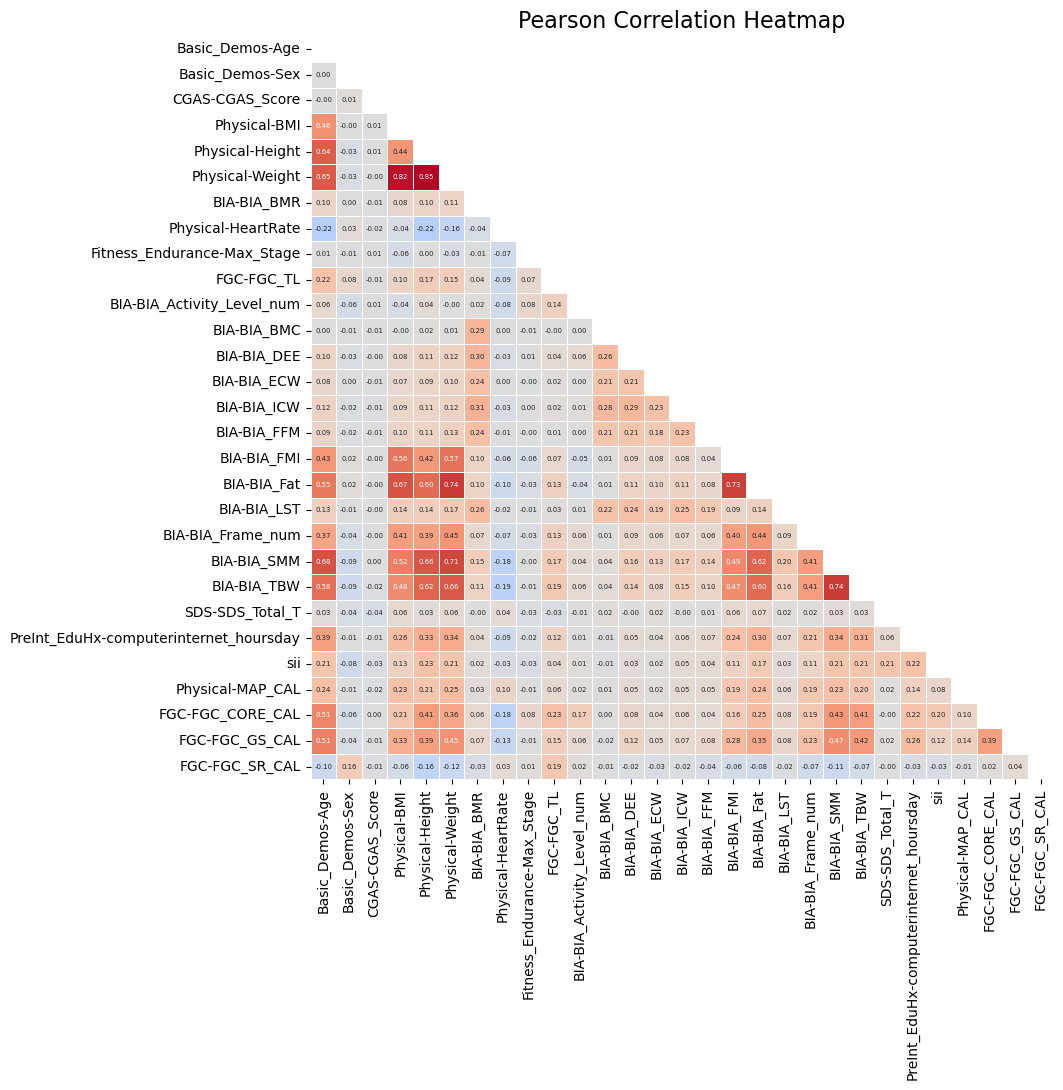

In [57]:
# column selection
df_corr = df[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## atributes 

In [58]:
df_clean=df[['id', 'Basic_Demos-Age', 
       'Basic_Demos-Sex',
       'Physical-BMI', 
       'Physical-Height', 
       'Physical-Weight',
       'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 
       'FGC-FGC_GS_CAL', 
       'FGC-FGC_SR_CAL',
       'BIA-BIA_BMR',
       'BIA-BIA_Activity_Level_num', 
       'BIA-BIA_BMC',
       'BIA-BIA_DEE',
       'BIA-BIA_FFM', 
       'BIA-BIA_Fat', 
       'BIA-BIA_Frame_num', 
       'BIA-BIA_SMM',
       'BIA-BIA_TBW', 
        'sii'
       ]].copy()

In [59]:
df_clean.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Index: 8459 entries, 0 to 8459
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          8459 non-null   int64  
 1   Basic_Demos-Age             8459 non-null   int64  
 2   Basic_Demos-Sex             8459 non-null   int64  
 3   Physical-BMI                8459 non-null   float64
 4   Physical-Height             8459 non-null   float64
 5   Physical-Weight             8459 non-null   float64
 6   Physical-MAP_CAL            8459 non-null   float64
 7   FGC-FGC_CORE_CAL            8459 non-null   float64
 8   FGC-FGC_GS_CAL              8459 non-null   float64
 9   FGC-FGC_SR_CAL              8459 non-null   float64
 10  BIA-BIA_BMR                 8459 non-null   float64
 11  BIA-BIA_Activity_Level_num  8459 non-null   float64
 12  BIA-BIA_BMC                 8459 non-null   float64
 13  BIA-BIA_DEE                 8459 non-n

In [60]:
df_clean[df_clean['Physical-BMI']<6]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii


In [61]:
file_path = "../1.DATASET/cmi_internet.csv"
df_org=pd.read_csv(file_path)
list1 = [4009, 4759,4837,4957,5518,5761,5780,5861,6844]

df_org[df_org.id.isin(list1) == True]


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
4009,4009,Summer,12,0,Winter,60.5,Summer,23.980762,63.66,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,1.0,0.0
4759,4759,Fall,15,0,Fall,NaN,Summer,17.553132,70.90,3.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,2.0,0.0
4837,4837,Spring,9,1,Fall,NaN,Spring,20.281036,57.88,2.3,...,NaN,NaN,NaN,NaN,Summer,40.5,45.0,Spring,1.0,0.0
4957,4957,Winter,8,1,Winter,60.0,Spring,18.089762,51.08,2.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
5518,5518,Summer,15,1,Summer,61.5,Fall,25.254572,49.14,2.5,...,NaN,NaN,NaN,NaN,Spring,34.5,49.5,Spring,2.0,0.0
5761,5761,Winter,8,0,Spring,NaN,Spring,NaN,57.42,0.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Winter,0.0,2.0
5780,5780,Fall,9,1,Winter,62.0,Spring,21.485738,56.62,0.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Winter,0.0,0.0
5861,5861,Fall,8,1,Spring,71.0,Fall,17.484574,57.86,3.5,...,NaN,NaN,NaN,NaN,Winter,40.5,56.0,Fall,0.0,0.0
6844,6844,Summer,10,0,Fall,62.5,Summer,17.480237,69.19,2.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Summer,0.0,0.0


In [62]:
df_clean.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
count,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000,8459.000000,8460.000000,8460.000000,8460.000000,8460.000000,8460.000000
mean,4229.500000,10.240189,0.402364,19.398079,56.455933,92.172090,84.638161,15.563148,20.245747,8.404002,1216.773730,2.768913,7.269533,1977.751756,75.537319,21.227198,1.717376,30.687550,44.881702,0.443853
std,2442.335972,3.574680,0.490404,4.508203,7.772218,41.780564,9.718417,11.568799,5.638581,2.031050,1635.745040,0.824987,86.781179,2710.405449,240.863071,16.875175,0.567185,12.584939,14.289187,0.731014
min,0.000000,5.000000,0.000000,8.522436,33.000000,31.800000,37.666667,0.500000,0.100000,0.500000,813.397000,1.000000,0.009889,1073.450000,28.900000,0.026117,1.000000,4.655730,20.589200,0.000000
25%,2114.750000,7.000000,0.000000,16.492196,50.830000,62.600000,79.791667,8.000000,18.025000,7.500000,1030.413657,2.000000,3.349540,1602.306714,50.951966,10.444766,1.000000,22.702590,36.939644,0.000000
50%,4229.500000,10.000000,0.000000,17.937682,55.125000,77.811409,83.333333,12.787145,18.613018,8.500000,1115.380000,3.000000,4.515065,1805.265000,61.066200,15.811750,2.000000,26.062700,42.380000,0.000000
75%,6344.250000,12.000000,1.000000,21.232154,62.265000,113.400000,88.166667,20.500000,20.626092,9.000000,1290.500000,3.000000,5.812928,2095.450000,76.500000,27.341580,2.000000,36.479100,47.487629,1.000000
max,8459.000000,22.000000,1.000000,59.132048,78.500000,315.923401,164.333333,150.000000,115.100000,21.000000,83152.200000,5.000000,4115.360000,124728.000000,8799.080000,153.820000,3.000000,215.413000,143.762000,3.000000


In [ ]:
#df[df["Physical-Weight"] < df["BIA-BIA_Fat"]] ##1
#df[["Physical-Weight", "BIA-BIA_FFM"]][df["Physical-Weight"] < df["BIA-BIA_FFM"]] ##847
#df[["Physical-Weight", "BIA-BIA_TBW"]][df["Physical-Weight"] < df["BIA-BIA_TBW"]] ## 108
#df[["BIA-BIA_SMM", "BIA-BIA_FFM"]][df["BIA-BIA_FFM"] < df["BIA-BIA_SMM"]] ## 12
df[["BIA-BIA_SMM", "Physical-Weight"]][df["Physical-Weight"] < df["BIA-BIA_SMM"]] ##12

,BIA-BIA_SMM,Physical-Weight
1045,50.94020,44.192196
1287,83.83745,49.600000
1464,62.70090,44.192196
2738,83.83745,49.200000
2770,83.83745,75.600000
3147,83.83745,52.800000
3162,62.70090,47.302107
3205,83.83745,70.400000
3729,83.83745,77.185617
3842,62.70090,44.192196
